Directions

- Install the necessary libraries from the requirements.txt file into your corresponding virtual environment. Make sure you start JupyterLab with the extra data rate argument.
- Start a new notebook in JupyterLab and import all of the libraries you’ll need.
- Load the twentieth-century data that you scraped in Exercise 1.4.
- Tokenize the words from the text and create a bar chart to plot the 10 most common words.
- Remove stop words (and punctuation marks if necessary), and rerun the plot. What has changed? Comment on your impressions in a markdown cell under the plot.
- Create a tags list using TextBlob.
- Create a list of the Top 10 POS tags for words that appear in the article.
- Plot this list in a bar chart using the seaborn library. Note: If you were with us for the Data Immersion Program, you’ve already learned about seaborn in Achievement 4. If Seaborn is new to you, use this introductory resource to walk you through it.
- Create three bar plots with the top 15 POS labels—one each for nouns, verbs, and adjectives. Analyzing the results—what do you think stands out in these frequencies? Comment on your impressions in a Markdown cell under the plot.
- Create a dataframe with the countries and the number of times they’re mentioned in your text (remember—you’ll need to use the countries lookup list if you didn’t scrape one in the previous task).
- Create a plot showing the frequency of the number of times these countries are mentioned in the text. Is there anything in particular you notice in this plot? Describe your findings in a Markdown cell underneath the plot.
- Save your notebook, download it, push the changes to your GitHub repo, and send it to your mentor for review.

In [1]:
#import libraries
from textblob import TextBlob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import nltk
import re
from collections import Counter

# NLTK downloads
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

sns.set()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [2]:
# Import txt file
#this clean txt file I prepared it in task 1.6, strangely.
#it will make this task much easier:
with open('20th_century_events_clean.txt', 'r', errors='ignore') as file: 
   data = file.read().replace( '\n', ' ')

#### Tokenization

In [3]:
# Word tokenization
from nltk.tokenize import word_tokenize
tokenized_word = word_tokenize(data)
print(tokenized_word) 

['The', '20th', 'century', 'changed', 'the', 'world', 'in', 'unprecedented', 'ways', '.', 'The', 'World', 'Wars', 'sparked', 'tension', 'between', 'countries', 'and', 'led', 'to', 'the', 'creation', 'of', 'atomic', 'bombs', ',', 'the', 'Cold', 'War', 'led', 'to', 'the', 'space', 'race', 'and', 'the', 'creation', 'of', 'space-based', 'rockets', ',', 'and', 'the', 'World', 'Wide', 'Web', 'was', 'created', '.', 'These', 'advancements', 'have', 'played', 'a', 'significant', 'role', 'in', 'citizens', "'", 'lives', 'and', 'shaped', 'the', '21st', 'century', 'into', 'what', 'it', 'is', 'today', '.', 'Historic', 'events', 'in', 'the', '20th', 'century', 'World', 'at', 'the', 'beginning', 'of', 'the', 'century', 'Edwardian', 'era', 'Map', 'of', 'colonial', 'and', 'land-based', 'empires', 'throughout', 'the', 'world', 'in', '1914', 'The', 'new', 'beginning', 'of', 'the', '20th', 'century', 'marked', 'significant', 'changes', '.', 'The', '1900s', 'saw', 'the', 'decade', 'herald', 'a', 'series', '

In [4]:
#frequency distribution
from nltk.probability import FreqDist
dist_words = FreqDist(tokenized_word)
print(dist_words) 

<FreqDist with 4620 samples and 20625 outcomes>


In [5]:
#most common words
dist_words.most_common(10)

[('.', 1335),
 ('the', 1133),
 (',', 979),
 ('of', 620),
 ('and', 412),
 ('to', 326),
 ('The', 319),
 ('in', 306),
 ("''", 276),
 ('``', 272)]

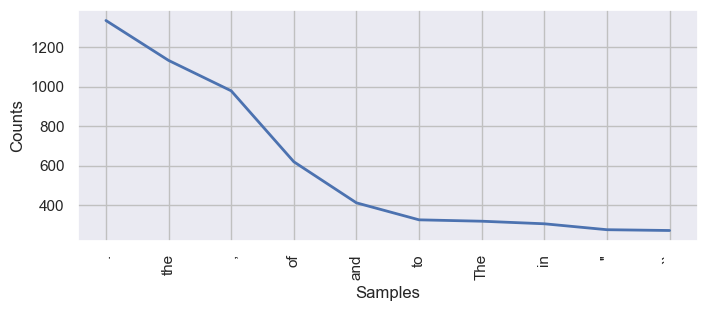

In [6]:
# Frequency Distribution Plot
plt.figure(figsize=(8, 3))
dist_words.plot(10,cumulative = False)
plt.show()

### Removing StopWords (punctuation marks and other)

In [7]:
# Defining stopwords
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))
print(stop_words)

{"it'd", 'but', "doesn't", 'about', 'we', "isn't", "you've", 'herself', 'be', "we'd", 've', 'here', 'been', "we'll", 'o', 'were', 'you', 'how', 'does', 'than', 'or', 'her', 'itself', "we've", 'myself', 'as', 'off', 'needn', 'which', 'its', "we're", 'd', "aren't", 'further', "wasn't", 'few', "mustn't", 'some', 'there', "you'd", 'do', 're', 'own', 'where', 'it', 'themselves', 'from', 'above', 'isn', 'did', 'so', 'my', "they're", 'me', 'won', 'up', 'after', "you're", 'again', 'not', 'same', 'any', 'under', "you'll", "should've", 'hers', 'down', "won't", 'am', 'into', "mightn't", 'shan', 'was', 'by', 'didn', 'him', 'all', "couldn't", "needn't", "they'll", 'through', 'the', 'them', 'below', 'weren', 'being', 'is', 'when', 'theirs', 'aren', 'now', 'each', 'too', 'over', 'just', 'ma', 'shouldn', 'couldn', 'm', 'most', "weren't", 'whom', 'wasn', 'ain', 'are', 'has', "he'd", "i'll", 'doesn', "it's", 'should', 'such', 'during', 'an', 'mightn', 'ourselves', "wouldn't", 'yourself', 'hadn', 'with',

In [8]:
# Removing stopwords in words
filtered_words = [] # creates an empty list
for word in tokenized_word:
      if word not in stop_words:
           filtered_words.append(word)

In [9]:
# Create a new FreqDist for filtered_words
dist_words_filter = FreqDist(filtered_words)
print(dist_words_filter)

<FreqDist with 4517 samples and 15826 outcomes>


<Axes: xlabel='Samples', ylabel='Counts'>

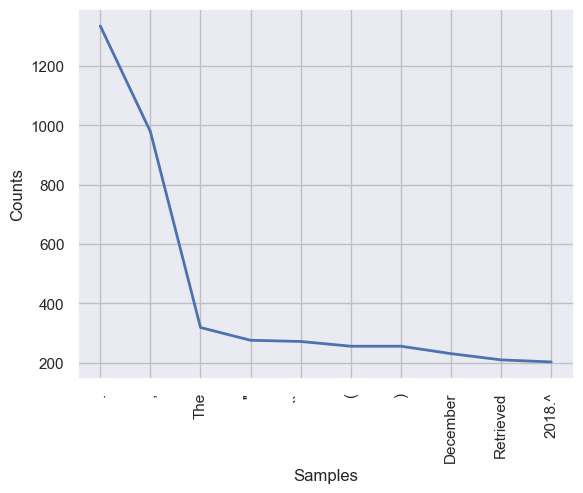

In [10]:
dist_words_filter.plot(10)

There's a lot of punctuation marks. Let's take them out.

In [11]:
# Substitute all punctuation marks with a space
sans_punc = re.sub("[^a-zA-Z]",  # Search for all non-letters
                        " ",        # Replace all non-letters with spaces
                        str(filtered_words))

In [12]:
# Word tokenization
tokenized_word_2 = word_tokenize(sans_punc)
print (tokenized_word_2)

['The', 'th', 'century', 'changed', 'world', 'unprecedented', 'ways', 'The', 'World', 'Wars', 'sparked', 'tension', 'countries', 'led', 'creation', 'atomic', 'bombs', 'Cold', 'War', 'led', 'space', 'race', 'creation', 'space', 'based', 'rockets', 'World', 'Wide', 'Web', 'created', 'These', 'advancements', 'played', 'significant', 'role', 'citizens', 'lives', 'shaped', 'st', 'century', 'today', 'Historic', 'events', 'th', 'century', 'World', 'beginning', 'century', 'Edwardian', 'era', 'Map', 'colonial', 'land', 'based', 'empires', 'throughout', 'world', 'The', 'new', 'beginning', 'th', 'century', 'marked', 'significant', 'changes', 'The', 's', 'saw', 'decade', 'herald', 'series', 'inventions', 'including', 'automobile', 'airplane', 'radio', 'broadcasting', 'saw', 'completion', 'Panama', 'Canal', 'The', 'scramble', 'Africa', 'continued', 's', 'resulted', 'wars', 'genocide', 'across', 'continent', 'The', 'atrocities', 'Congo', 'Free', 'State', 'shocked', 'civilized', 'world', 'From', 'Fir

In [13]:
# Create a new FreqDist
dist_words_filter_2 = FreqDist(tokenized_word_2)

<Axes: xlabel='Samples', ylabel='Counts'>

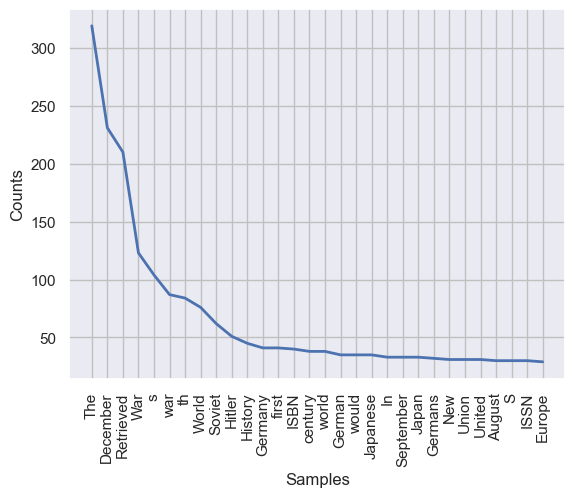

In [14]:
dist_words_filter_2.plot(30)

Much better now.

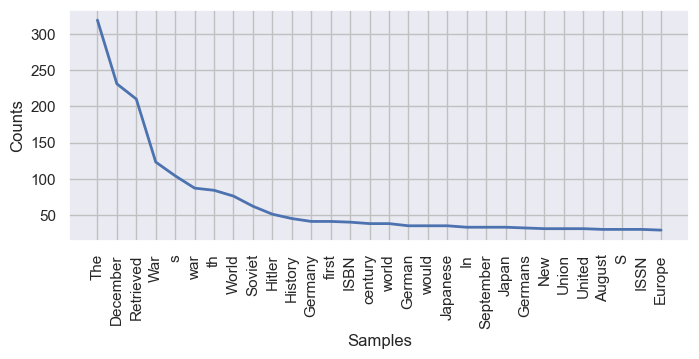

In [15]:
#freq distribution plot
plt.figure(figsize =(8,3))
dist_words_filter_2.plot(30, cumulative = False)
plt.show()

In [16]:
dist_words_filter_2.most_common(30)

[('The', 319),
 ('December', 231),
 ('Retrieved', 210),
 ('War', 123),
 ('s', 104),
 ('war', 87),
 ('th', 84),
 ('World', 76),
 ('Soviet', 62),
 ('Hitler', 51),
 ('History', 45),
 ('Germany', 41),
 ('first', 41),
 ('ISBN', 40),
 ('century', 38),
 ('world', 38),
 ('German', 35),
 ('would', 35),
 ('Japanese', 35),
 ('In', 33),
 ('September', 33),
 ('Japan', 33),
 ('Germans', 32),
 ('New', 31),
 ('Union', 31),
 ('United', 31),
 ('August', 30),
 ('S', 30),
 ('ISSN', 30),
 ('Europe', 29)]

#### Notes:
There are some words, like 's', 'th' and 'II', that show often, deriving from the s after the apostrophe, II from the World War, th I'm not sure, but probably from 20th and 19th centuries.

### POS Tagging (Part of Speech) using textblob

In [17]:
new_stopwords = ["The", "s", 'th', 'In', 'II']

filtered = []
for word in tokenized_word_2:
     if word not in new_stopwords:
        filtered.append(word)

In [18]:
#AI assistant
# If you're in a Jupyter notebook, import the time module instead
import time

start_time = time.time()

#text = TextBlob(str(filtered)) 
#this line of code is giving errors, because it's adding punctuation further ahead. 
#let's change it for other:

text = TextBlob(" ".join(filtered))
end_time = time.time()
print(f"Execution time: {end_time - start_time} seconds")

Execution time: 0.005110979080200195 seconds


In [ ]:
tag_list = text.tags

In [ ]:
df_text = pd.DataFrame(tag_list)
df_text.columns = ['Words', "Word type"]

In [ ]:
df_text.head(30)

### creating the bar charts:
#### top 10 tags

In [ ]:
#counting top tags:
top_10_tags = df_text['Word type'].value_counts().head(10).reset_index()
top_10_tags.columns = ['Word type', 'Words']
print(top_10_tags)

In [ ]:
#plot top 10 tags
plt.figure(figsize=(12, 6))
sns.barplot(data=top_10_tags, x='Word type', y='Words')
plt.title('Top 10 POS Tags')
plt.xlabel('POS Tag')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Nouns

In [ ]:
#counting top words:
top_15_words = df_text['Words'].value_counts().head(15).reset_index()
top_15_words.columns = ['Words', 'Count']
print(top_15_words)

In [ ]:
#plot
plt.figure(figsize=(12, 6))
sns.barplot(data=top_15_words, x='Words', y='Count')
plt.title('Top 15 POS Nouns')
plt.xlabel('POS Noun')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Verbs

In [ ]:
# Filter verbs (all verb types in Penn Treebank tagset)
df_verbs = df_text[(df_text['Word type'] == 'VB') | 
                   (df_text['Word type'] == 'VBD') | 
                   (df_text['Word type'] == 'VBG') | 
                   (df_text['Word type'] == 'VBN') | 
                   (df_text['Word type'] == 'VBP') | 
                   (df_text['Word type'] == 'VBZ')]
df_verbs.columns = ['Word', 'Occurrences']
x = df_verbs.groupby('Word').count().reset_index()
y = x.sort_values(by=['Occurrences'], ascending=False)
top15_verbs = y.nlargest(15, 'Occurrences')

In [ ]:
df_verbs.head(20)

In [ ]:
#plot
plt.figure(figsize=(12, 5))
with sns.dark_palette("xkcd:green", 15):
    sns.barplot(x='Word', y='Occurrences',
    saturation=0.9, data=top15_verbs).set_title('20th Century Events - Most Frequently Used Verbs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Adjectives

In [ ]:
# Filter adjectives
df_adj = df_text[(df_text['Word type'] == 'JJ') | 
                 (df_text['Word type'] == 'JJR') | 
                 (df_text['Word type'] == 'JJS')]
df_adj.columns = ['Word', 'Occurrences']
x = df_adj.groupby('Word').count().reset_index()
y = x.sort_values(by=['Occurrences'], ascending=False)
top15_adj = y.nlargest(15, 'Occurrences')

In [ ]:
#plot
plt.figure(figsize=(12, 5))
with sns.dark_palette("xkcd:orange", 15):
    sns.barplot(x='Word', y='Occurrences',
    saturation=0.9, data=top15_adj).set_title('20th Century Events - Most Frequently Used Adjectives')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

O Penn Treebank é um projecto da Universidade da Pennsylvania que criou um corpus de textos em inglês anotados manualmente com tags gramaticais. O seu sistema de tags tornou-se o standard mais usado em NLP para o inglês.

Porquê tantas tags para verbos?
Em vez de ter apenas uma tag VERB (como o spaCy), o Penn Treebank é muito mais granular:

#### Penn Treebank Tagset

##### Verbs
| Tag | Meaning | Example |
|-----|---------|---------|
| VB  | Verb, base form | "invade" |
| VBD | Verb, past tense | "invaded" |
| VBG | Verb, gerund | "invading" |
| VBN | Verb, past participle | "invaded" |
| VBP | Verb, present tense | "invade" |
| VBZ | Verb, present tense 3rd person | "invades" |

##### Adjectives
| Tag | Meaning | Example |
|-----|---------|---------|
| JJ  | Adjective | "small" |
| JJR | Adjective, comparative | "smaller" |
| JJS | Adjective, superlative | "smallest" |

##### Nouns
| Tag | Meaning | Example |
|-----|---------|---------|
| NN  | Noun, singular | "country" |
| NNS | Noun, plural | "countries" |
| NNP | Proper noun, singular | "France" |
| NNPS| Proper noun, plural | "Germans" |

### List of Countries scraped from Wikipedia:
##### There's a notebook with thar procedure made.
-Let's go with that file I created:

In [ ]:
# Load the file:
df_countries = pd.read_csv('countries_list.csv')
countries_list = df_countries['country'].tolist()

In [ ]:
print(countries_list)

In [ ]:
#count how many times each country is mentioned in the text
country_counts = []

for country in countries_list:
    count = data.count(country) #using 'data', the original txt 
    country_counts.append({'country': country, 'count': count})

#convert to DataFrame
df_country_counts = pd.DataFrame(country_counts)

#sort by count descending
df_country_counts = df_country_counts.sort_values(by='count', ascending=False).reset_index(drop=True)
print(df_country_counts.head(20))

#### Frequency Distribution

In [ ]:
#filter out countries with 0 mentions
df_plot = df_country_counts[df_country_counts['count'] > 0]

plt.figure(figsize=(14, 6))
sns.barplot(data=df_plot, x='country', y='count')
plt.title('Frequency of Country Mentions in 20th Century Events Text')
plt.xlabel('Country')
plt.ylabel('Number of Mentions')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(20, 8))  # Aumentei o tamanho
sns.barplot(data=df_plot, x='country', y='count')
plt.title('Frequency of Country Mentions in 20th Century Events Text')
plt.xlabel('Country')
plt.ylabel('Number of Mentions')
plt.xticks(rotation=90, fontsize=8)  # Texto mais pequeno para caber
plt.tight_layout()
plt.savefig('country_mentions.png', dpi=150, bbox_inches='tight')  # Guarda a imagem
plt.show()

### Pulling files to Github Repo

In [ ]:
#adding to github repo
!git add dataviz_python.ipynb countries_list.csv countries_list_scrape.ipynb 
!git commit -m "Add 20th century POS analysis and vizzes notebook, country web scraping notebook and countries list"
!git push -u origin master